#TASK 3 — Car Price Prediction with Machine Learning

##Markdown Title

# Car Price Prediction with Machine Learning

### CodeAlpha Data Science Internship — Task 3

## Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of cars based on various car-related features.

The project includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Regression Model Training
- Model Evaluation
- Actual vs Predicted Visualization
- Conclusion

##Markdown Introduction

## Introduction

Car price prediction is one of the most common applications of machine learning in the automobile industry.

The price of a vehicle depends on multiple factors such as manufacturing year, mileage, fuel type, transmission, engine capacity, ownership history, and brand value.

In this project, Python and Scikit-learn are used to preprocess the car dataset, analyze important relationships between variables, train regression models, and evaluate their predictive performance.

The final model will estimate the selling price of cars using historical vehicle data.

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


##Uploading Data Set

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data.csv


##Loading Data Set

In [ ]:
import os

filename = list(uploaded.keys())[0]

if filename.endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
elif filename.endswith(".xls"):
    df = pd.read_excel(filename)

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


##Data Set Shape

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 301
Columns: 9


##Column Names

In [ ]:
print("Dataset Columns:\n")

for col in df.columns:
    print(col)

Dataset Columns:

Car_Name
Year
Selling_Price
Present_Price
Driven_kms
Fuel_Type
Selling_type
Transmission
Owner


##Data Set Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


##Statistical Summary

In [ ]:
df.describe(include="all")

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.642584,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


#DATA CLEANING

##Cleaning Column Names

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'owner']


##Missing Values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
car_name,0,0.0
year,0,0.0
selling_price,0,0.0
present_price,0,0.0
driven_kms,0,0.0
fuel_type,0,0.0
selling_type,0,0.0
transmission,0,0.0
owner,0,0.0


##Finding Duplicate Values

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


##Removing Duplicate Values

In [ ]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (299, 9)


##Detecting Price Column

In [ ]:
possible_targets = [
    "selling_price",
    "price",
    "car_price",
    "sellingprice"
]

target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

print("Detected Target Column:", target)

Detected Target Column: selling_price


##Converting Numeric Columns

In [ ]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_name       299 non-null    object 
 1   year           299 non-null    int64  
 2   selling_price  299 non-null    float64
 3   present_price  299 non-null    float64
 4   driven_kms     299 non-null    int64  
 5   fuel_type      299 non-null    object 
 6   selling_type   299 non-null    object 
 7   transmission   299 non-null    object 
 8   owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


#EXPLORATORY DATA ANALYSIS

##Target Distribution

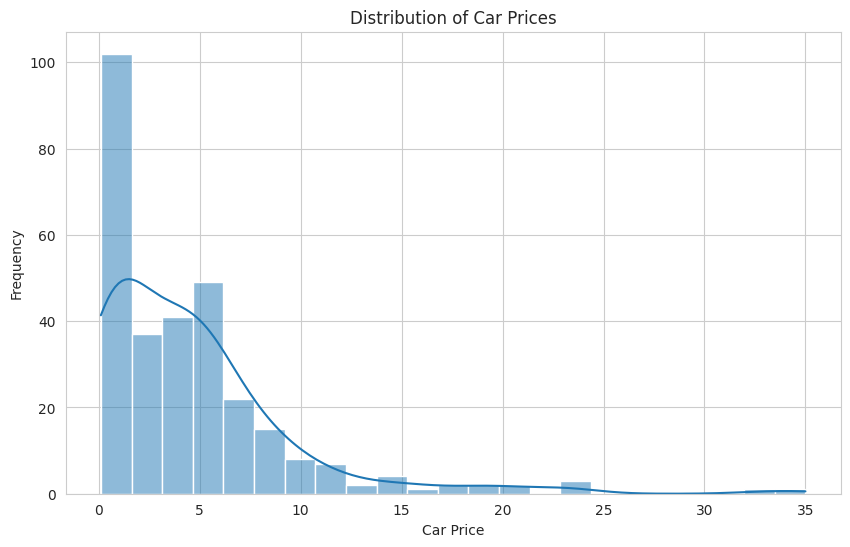

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df[target], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Car Price")
plt.ylabel("Frequency")

plt.show()

##Box PLot of Price

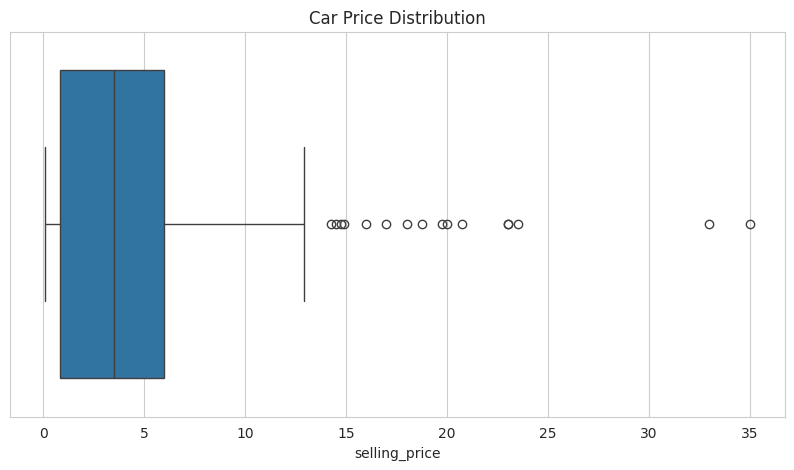

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df[target])

plt.title("Car Price Distribution")

plt.show()

##Correlation Heatmap

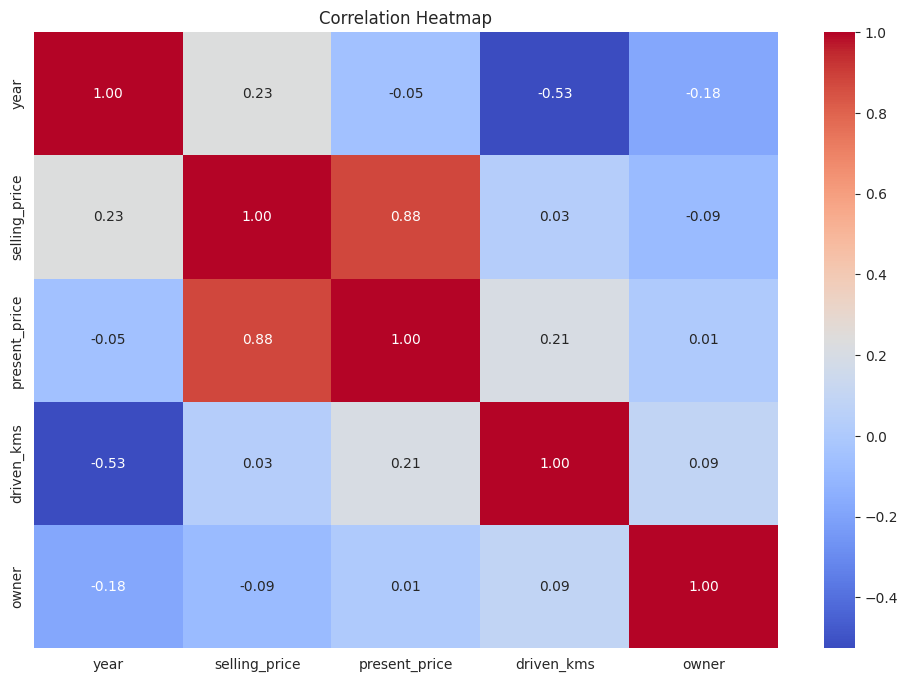

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##Top 10 Expensive Cars

In [ ]:
df[[target]].sort_values(
    by=target,
    ascending=False
).head(10)

,selling_price
86,35.00
64,33.00
63,23.50
82,23.00
51,23.00
96,20.75
59,19.99
66,19.75
62,18.75
52,18.00


##Brand Analysis

In [ ]:
brand_candidates = [
    "brand",
    "company",
    "manufacturer",
    "name"
]

brand_col = None

for col in brand_candidates:
    if col in df.columns:
        brand_col = col
        break

print("Detected Brand Column:", brand_col)

Detected Brand Column: None


##Average Price by Brand

In [ ]:
if brand_col is not None:

    brand_price = (
        df.groupby(brand_col)[target]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12,6))

    brand_price.plot(kind="bar")

    plt.title("Top 15 Brands by Average Car Price")
    plt.xlabel("Brand")
    plt.ylabel("Average Price")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("Brand column not found.")

Brand column not found.


#FEATURE ENGINEERING

##Detecting Numeric and Categoral Features

In [ ]:
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['year', 'present_price', 'driven_kms', 'owner']

Categorical Features:
['car_name', 'fuel_type', 'selling_type', 'transmission']


##Removing Unwanted Columns

In [ ]:
id_candidates = ["id","unnamed:_0","index"]

for col in id_candidates:
    if col in X.columns:
        X = X.drop(columns=[col])

print("Updated Feature Shape:", X.shape)

Updated Feature Shape: (299, 8)


##Train Test Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (239, 8)
Testing Samples: (60, 8)


##Creating PreProcessing Pipeline

In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include="object").columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#MODEL 1 - Linear Regression

In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


##Predictions

In [ ]:
y_pred_linear = linear_model.predict(X_test)

##Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE : 1.436088702137748
MSE : 7.03987935468609
RMSE: 2.6532770972301574
R² Score: 0.7268533841782681


#MODEL 2 - Random Forest Regressor

In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


##Random Forest Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)

##Random Forest Evaluation

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE : 1.3510574999999998
MSE : 10.24211010204168
RMSE: 3.200329686460706
R² Score: 0.6026071510182855


#MODEL COMPARISION

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.436089,2.653277,0.726853
1,Random Forest,1.351057,3.200330,0.602607


##Visualization

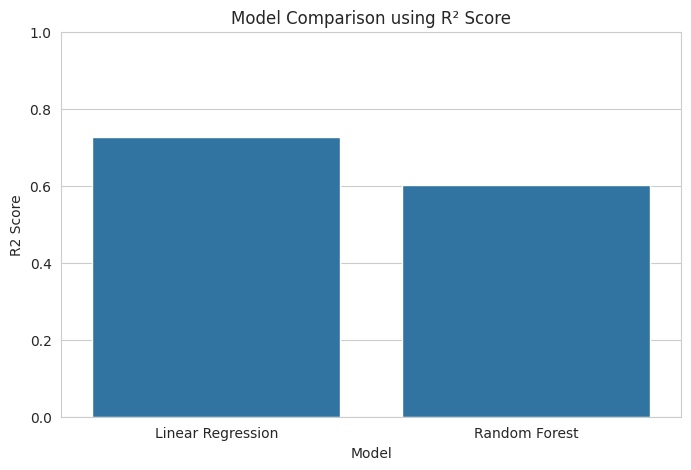

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison using R² Score")

plt.ylim(0,1)

plt.show()

#ACTUAL VS PREDICTED

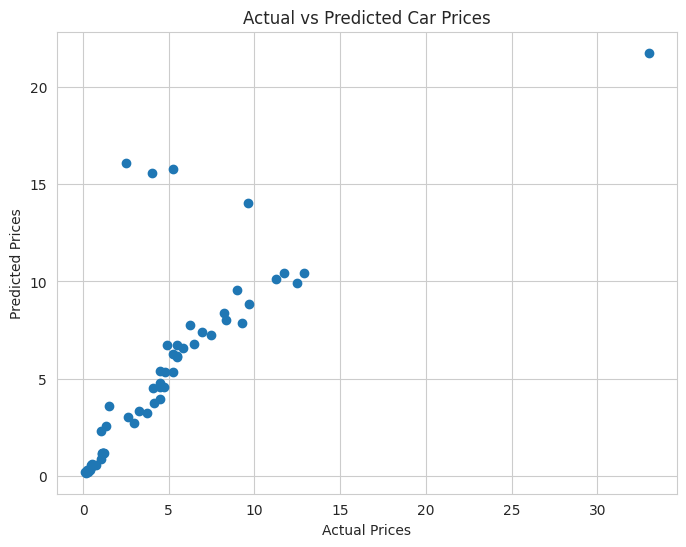

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

#RESIDUAL ANALYSIS

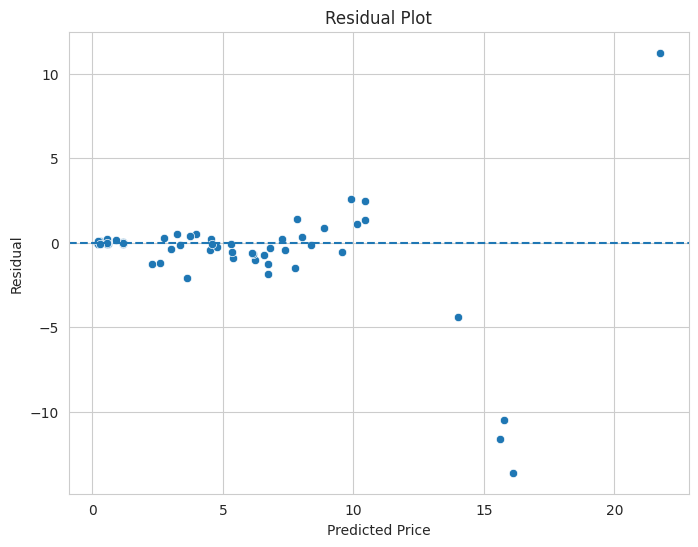

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

#SAMPLE PREDICTIONS

In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,9.54770
1,8.35,8.02100
2,0.45,0.44175
3,7.45,7.25425
4,5.25,15.76020
5,5.25,5.32100
6,5.85,6.58835
7,1.15,1.19125
8,9.25,7.84975
9,0.38,0.30660


#BEST MODEL

In [ ]:
if r2_rf > r2:
    best_model = "Random Forest Regressor"
    best_score = r2_rf
else:
    best_model = "Linear Regression"
    best_score = r2

print("Best Performing Model:", best_model)
print("Best R² Score:", best_score)

Best Performing Model: Linear Regression
Best R² Score: 0.7268533841782681


#KEY INSIGHTS

In [ ]:
print("========== PROJECT INSIGHTS ==========\n")

print("Total Records:", len(df))

print("Total Features:", X.shape[1])

print("Best Model:", best_model)

print("Best R² Score:", round(best_score,4))

print("Highest Car Price:", df[target].max())

print("Lowest Car Price:", df[target].min())

print("Average Car Price:", round(df[target].mean(),2))

print("\n======================================")

========== PROJECT INSIGHTS ==========

Total Records: 299
Total Features: 8
Best Model: Linear Regression
Best R² Score: 0.7269
Highest Car Price: 35.0
Lowest Car Price: 0.1
Average Car Price: 4.59



#Conclusion

In this project, a machine learning regression model was developed to predict car prices using historical automobile data.

The dataset was cleaned and analyzed using exploratory data analysis techniques. Missing values, duplicate records, numerical variables, and categorical variables were handled through data preprocessing.

Two regression models were trained:

- Linear Regression
- Random Forest Regressor

Their performances were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The comparison of both models helped identify the better-performing regression algorithm for predicting car prices.

This project demonstrates the complete machine learning workflow including data preprocessing, feature engineering, model training, evaluation, and prediction using Python and Scikit-learn.